# Práctico 3 - Expresión Genética Ejercicio 1) - Modelo de Goodwin

Consideramos el modelo de Goodwin, un modelo simple de regulación genética. El modelo de Goodwin es un sistema de ecuaciones diferenciales que describe la evolución temporal del núcleo de ADN.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from scipy.integrate import solve_ivp

In [3]:
# Definimos la función de represión
def g_R(p, a, b, c, h):
    return a/(b + c * p**h)

# Definimos las ecuaciones diferenciales del modelo de Goodwin
def goodwin(t, y, alpha_m, beta_m, alpha_e, beta_e, alpha_p, beta_p, a, b, c, h):
    m, e, p = y
    dmdt = alpha_m * g_R(p, a, b, c, h) - beta_m * m
    dedt = alpha_e * m - beta_e * e
    dpdt = alpha_p * e - beta_p * p
    return [dmdt, dedt, dpdt]

Analicemos la dinámica para distintos valores del exponente de Hill $h$

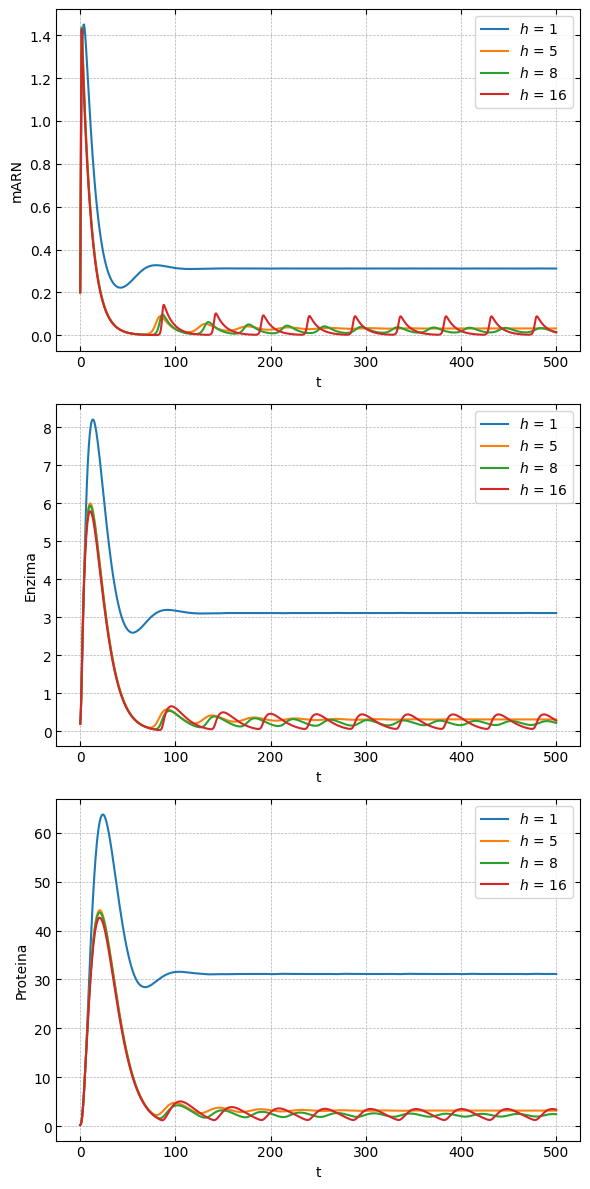

In [4]:
# Consideramos todos los parámetros iguales
alpha = 1
beta = 0.1
a = 1

# Elegímos distintos valores de h
hs = [1, 5, 8, 16]

# Definimos los valores iniciales
y0 = [0.2, 0.2, 0.2]

# Definimos los tiempos de integración
t_span = (0, 500)

fig, ax = plt.subplots(3, 1, figsize=(6, 12))

for h in hs:
    sol = solve_ivp(goodwin, t_span, y0, args=(alpha, beta, alpha, beta, alpha, beta, a, a, a, h), dense_output=True)
    t = np.linspace(0, 500, 1000)
    y = sol.sol(t)
    ax[0].plot(t, y[0], label=f'$h$ = {h}')
    ax[1].plot(t, y[1], label=f'$h$ = {h}')
    ax[2].plot(t, y[2], label=f'$h$ = {h}')

ax[0].set_xlabel('t')
ax[0].set_ylabel('mARN')
ax[0].legend(loc='best')
ax[0].tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax[0].grid(linestyle='--', linewidth=0.5)


ax[1].set_xlabel('t')
ax[1].set_ylabel('Enzima')
ax[1].legend(loc='best')
ax[1].tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax[1].grid(linestyle='--', linewidth=0.5)

ax[2].set_xlabel('t')
ax[2].set_ylabel('Proteina')
ax[2].legend(loc='best')
ax[2].tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax[2].grid(linestyle='--', linewidth=0.5)


plt.tight_layout()
plt.savefig('goodwinOscilaciones.pdf')
plt.show()



# plt.xlabel('t')
# plt.ylabel('mARN')
# plt.gca().xaxis.set_major_locator(plt.AutoLocator())
# plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
# plt.gca().yaxis.set_major_locator(plt.AutoLocator())
# plt.gca().yaxis.set_minor_locator(AutoMinorLocator())
# plt.gca().yaxis.set_ticks_position('both')
# plt.gca().xaxis.set_ticks_position('both')
# plt.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=12)
# plt.grid(linestyle='--', linewidth=0.5)
# plt.legend(loc = 'best')
# plt.tight_layout()
# # plt.savefig('goodwinOscilaciones.pdf')
# plt.show()

Vemos que obtenemos oscilaciones amortiguadas para $h=5$ y oscilaciones sostenidas para $h=8$. Veamos que sucede si aumentamos el valor de $\beta$ a 1

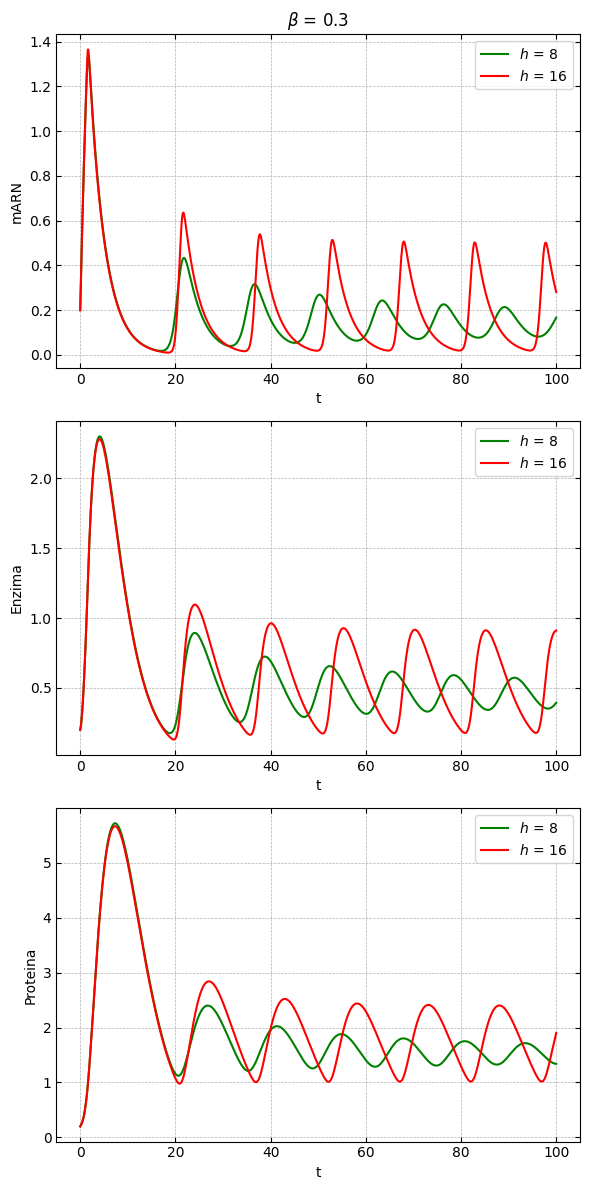

In [20]:
# Consideramos todos los parámetros iguales
alpha = 1
beta = 0.3
a = 1

# Elegímos distintos valores de h
hs = [8, 16]

# Definimos los valores iniciales
y0 = [0.2, 0.2, 0.2]
# Definimos los tiempos de integración
t_span = (0, 100)

fig, ax = plt.subplots(3, 1, figsize=(6, 12))

colors = ['green', 'green', 'green', 'red', 'red', 'red']

for h in hs:
    sol = solve_ivp(goodwin, t_span, y0, args=(alpha, beta, alpha, beta, alpha, beta, a, a, a, h), dense_output=True)
    t = np.linspace(0, 100, 1000)
    y = sol.sol(t)
    ax[0].plot(t, y[0], label=f'$h$ = {h}', color = colors.pop(0))
    ax[1].plot(t, y[1], label=f'$h$ = {h}', color = colors.pop(0))
    ax[2].plot(t, y[2], label=f'$h$ = {h}', color = colors.pop(0))

ax[0].set_xlabel('t')
ax[0].set_ylabel('mARN')
ax[0].set_title(f'$\\beta$ = {beta}')
ax[0].legend(loc='best')
ax[0].tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax[0].grid(linestyle='--', linewidth=0.5)


ax[1].set_xlabel('t')
ax[1].set_ylabel('Enzima')
ax[1].legend(loc='best')
ax[1].tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax[1].grid(linestyle='--', linewidth=0.5)

ax[2].set_xlabel('t')
ax[2].set_ylabel('Proteina')
ax[2].legend(loc='best')
ax[2].tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax[2].grid(linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig(f'goodwin{beta}.pdf')
plt.show()